In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# --- Load the dataset ---
file_path = "collision_dataset_100000_H2_DSMC_sampling.csv"
# file_path = "collision_dataset_100000_H2.csv"
# file_path = "LB_collision_data.csv"

# Try space-delimited first; if that fails, fall back to commas
df = pd.read_csv(file_path, sep=",")

# create test set
data = df.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle the data
data, data_test = data.iloc[:70000], data.iloc[70000:].reset_index(drop=True)

# --- Basic info ---
print("Columns:", data.columns.tolist())
print("First few rows:")
print(data.head())

Columns: ['b', 'Etr', 'Er1', 'Er2', 'Etrp', 'Er1p', 'Er2p', 'Teq']
First few rows:
          b          Etr         Er1          Er2         Etrp        Er1p  \
0  0.042053  1592.685382  160.533045  1307.790673  1386.537360  128.841854   
1  0.497317   605.821433   56.487030   974.134069   636.023095   99.810584   
2  0.847443   309.061943  216.389502   334.260884   309.078690  198.436951   
3  1.141467   261.398550   65.673065   732.889434   294.313670   54.369180   
4  0.204248  1565.764246  155.516061    69.610367  1026.361270  631.884538   

          Er2p         Teq  
0  1545.530534  543.636792  
1   900.515140  831.424962  
2   352.114107  157.640946  
3   711.208547  490.005401  
4   132.546979  408.444094  


In [2]:
import os
import math
import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
from jax import random, jit, value_and_grad
from jax.example_libraries import stax, optimizers
import matplotlib.pyplot as plt

# -------------------------- Utilities --------------------------
def logit(x):
    x = jnp.clip(x, 1e-6, 1 - 1e-6)
    return jnp.log(x) - jnp.log1p(-x)

def inv_logit(z):
    return jnp.clip(1.0 / (1.0 + jnp.exp(-z)), 1e-12, 1 - 1e-12)

def preprocess_df(df):
    """
    Preprocess according to the paper's variable definitions:
    - Ec: total collision energy
    - eps_t: translational energy fraction  
    - eps_r_A: rotational energy fraction for molecule A
    """
    # Epsilon to prevent division by zero if total rotational energy is zero
    epsilon = 1e-12

    # --- Pre-collision values ---
    Etr = df["Etr"].values
    Er1 = df["Er1"].values
    Er2 = df["Er2"].values
    
    Ec = Etr + Er1 + Er2
    E_rot_total = Er1 + Er2
    
    # Calculate energy fractions (precollisional)
    eps_t = Etr / (Ec + epsilon)
    eps_r_A = Er1 / (E_rot_total + epsilon)
    
    # --- Post-collision values (for training targets) ---
    Etrp = df["Etrp"].values
    Er1p = df["Er1p"].values
    Er2p = df["Er2p"].values
    
    # Post-collision Ec is the same as pre-collision Ec
    E_rot_p_total = Er1p + Er2p

    # Calculate postcollisional energy fractions (targets)
    eps_t_prime = Etrp / (Ec + epsilon)
    eps_r_A_prime = Er1p / (E_rot_p_total + epsilon)
    
    # Apply transformations as per Equation 4.15
    x = np.stack([
        #np.log(Ec + epsilon),      # E_c^(p)
        logit(eps_t),              # eps_t^(p) 
        #logit(eps_r_A),            # eps_r,A^(p)
        #np.exp(df["b"].values)     # b^(p)  # Uncomment if including impact parameter
    ], axis=-1)
    
    y = np.stack([
        logit(eps_t_prime),        # eps_t'^(p)
        #logit(eps_r_A_prime)       # eps_r,A'^(p)
    ], axis=-1)
    
    return x.astype(np.float32), y.astype(np.float32), Ec

# -------------------------- Load and split dataset --------------------------
X, Y, Ec = preprocess_df(data)
X_test, Y_test, Ec_test = preprocess_df(data_test)
N = X.shape[0]


X_train, Y_train = X, Y
X_val, Y_val = X_test, Y_test
X_test, Y_test = X_test, Y_test

# -------------------------- MDN model --------------------------

def MDN_init(in_dim, hidden_size=8, M=20):
    """
    Initialize MDN according to Table 4.1:
    - Input layer: 3 neurons
    - Hidden layer: 8 neurons with ReLU
    - Output layer: M×5 neurons (linear activation)
    """
    init_fun, apply_fun = stax.serial(
        stax.Dense(hidden_size), 
        stax.Softplus,
        stax.Dense(M * 3)  # M components × 3 parameters each
    )
    return init_fun, apply_fun, M

def unpack_mdn_params(z, M, params=None, X0=jnp.array([[0.0]])):
    """Unpack MDN outputs and apply global last-mu offset for E[0]=0"""
    B = z.shape[0]
    z = z.reshape(B, M, 3)
    alpha_raw, mu, sigma_raw = z[...,0], z[...,1:2], z[...,2:3]

    # softmax alpha, softplus sigma
    alpha = jax.nn.softmax(alpha_raw, axis=-1) + 1e-12
    sigma = jax.nn.softplus(sigma_raw) + 1e-8

    if params is not None and X0 is not None:
        # Forward at x1=0
        z0 = apply_fun(params, X0)  # (1, M*3)
        z0 = z0.reshape(1, M, 3)
        alpha0 = jax.nn.softmax(z0[...,0], axis=-1)  # (1,M)
        mu0 = z0[...,1:2]                            # (1,M,1)

        # Weighted sum of first M-1 modes
        weighted_sum = (alpha0[:, :-1] * mu0[:, :-1, 0]).sum(axis=1)  # (1,)

        # Compute offset needed for last mu
        mu_last_offset = (-weighted_sum / alpha0[:, -1]) - mu0[:, -1, 0]  # (1,)

        # Apply same offset to last mu for all inputs
        mu = mu.at[:, -1, 0].add(mu_last_offset[0])

    return alpha, mu, sigma


def unpack_mdn_params(z, M, params=None):
    """Unpack MDN outputs into GMM parameters"""
    B = z.shape[0]
    z = z.reshape(B, M, 3)
    alpha_raw, mu, sigma_raw = z[...,0], z[...,1:2], z[...,2:3]
    
    # Ensure proper constraints
    alpha = jax.nn.softmax(alpha_raw, axis=-1) + 1e-12  # weights sum to 1
    sigma = jax.nn.softplus(sigma_raw) + 1e-8          # positive std devs
    return alpha, mu, sigma

@jit
def mdn_nll(params, x, y):
    """Negative log-likelihood loss function"""
    z = apply_fun(params, x)
    alpha, mu, sigma = unpack_mdn_params(z, M, params)
    
    # Expand y to match mixture dimensions
    y_exp = jnp.expand_dims(y, axis=1)  # (B, 1, 2)
    
    # Calculate log probability for each component
    var = sigma**2
    log_comp = -0.5 * jnp.sum((y_exp - mu)**2 / var, axis=-1) \
               - 0.5 * jnp.sum(jnp.log(2 * math.pi * var), axis=-1)
    
    # Mix with weights
    log_mix = jnp.log(alpha) + log_comp
    
    # Numerically stable log-sum-exp
    max_log = jnp.max(log_mix, axis=-1, keepdims=True)
    lse = max_log + jnp.log(jnp.sum(jnp.exp(log_mix - max_log), axis=-1, keepdims=True))
    nll = -jnp.mean(lse)

    return nll 

# -------------------------- Training setup --------------------------
# Use paper's hyperparameters
M = 20  # 20 Optimized number of mixture components # with b this can be smaller than 20~3, less complicated distribution
learning_rate = 1e-4  # Paper uses 1e-4
batch_size = 1000   # Paper uses 10,000 out of 1.000.000

init_fun, apply_fun, M = MDN_init(X.shape[1], hidden_size=8, M=M) # increase hidden size when adding b ~ 256 (mainly when using less mixtures)
_, params = init_fun(random.PRNGKey(1234), (-1, X.shape[1]))

# ADAM optimizer
opt_init, opt_update, get_params = optimizers.adam(learning_rate)
opt_state = opt_init(params)

@jit
def update(i, opt_state, x, y):
    params = get_params(opt_state)
    loss, grads = value_and_grad(mdn_nll)(params, x, y)
    return opt_update(i, grads, opt_state), loss

# -------------------------- Training loop --------------------------
def batch_indices(N, batch_size):
    """Precompute batch indices for faster iteration."""
    idx = np.random.permutation(N)
    return [idx[i:i+batch_size] for i in range(0, N, batch_size)]

# Early stopping variables
best_val_loss = float('inf')
patience = 10
patience_counter = 0
best_params = None

all_train_losses = []  # store per-iteration train loss
all_val_losses = []    # store per-epoch val loss

for epoch in range(1000):
    # Precompute batch indices once per epoch
    batches = batch_indices(len(X_train), batch_size)
    train_losses = []

    for i, batch_idx in enumerate(batches):
        xb, yb = X_train[batch_idx], Y_train[batch_idx]
        step_idx = epoch * len(batches) + i
        opt_state, loss = update(step_idx, opt_state, xb, yb)
        train_losses.append(float(loss))

    all_train_losses.append(np.mean(train_losses))  # record per iteration

    # Validation
    val_loss = float(mdn_nll(get_params(opt_state), X_val, Y_val))
    all_val_losses.append(val_loss)  # record per epoch

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_params = get_params(opt_state)
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch+1}: train_loss={np.mean(train_losses):.4f}, val_loss={val_loss:.4f}")
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

# Use best parameters
params = best_params if best_params is not None else get_params(opt_state)
test_loss = float(mdn_nll(params, X_test, Y_test))
print(f"Final test NLL: {test_loss:.4f}")

def mdn_sample_conserve(params, X, Ec, n_samples=1, key=random.PRNGKey(42)):
    """
    Sample post-collision energy fractions from MDN while conserving total energy.
    Returns energies Etr', Er1', Er2' such that sum = Ec always.
    """
    z = apply_fun(params, X)
    alpha, mu, sigma = unpack_mdn_params(z, M, params)
    
    N, M_, _ = mu.shape
    key_comp, key_noise = random.split(key)

    # Mixture component choice for all samples
    comp_idx = random.categorical(key_comp, jnp.log(alpha), shape=(n_samples, N))
    mu_s = mu[jnp.arange(N)[:, None], comp_idx.T]       # (N, n_samples, 1)
    sigma_s = sigma[jnp.arange(N)[:, None], comp_idx.T] # (N, n_samples, 1)

    # Sample Gaussian noise in one shot
    noise = random.normal(key_noise, mu_s.shape)
    draws = mu_s + noise * sigma_s  # (N, n_samples, 1)
    
    # Map back to [0,1] via inverse logit
    # draws[..., 0] corresponds to eps_t_prime
    # draws[..., 1] corresponds to eps_rA_prime
    eps_prime_fractions = inv_logit(draws)  # Shape: (N, n_samples, 1)
    
    eps_t_p = eps_prime_fractions[..., 0]   # Shape: (N, n_samples)
    key_noise, subkey = random.split(key_noise)
    eps_rA_p = jax.random.uniform(subkey, (N, n_samples))  # Random split for rotational energy

    Ec_exp = Ec[:, None]  # Shape (N, 1) to allow broadcasting

    # 1. Calculate post-collision translational energy
    Etr_p = eps_t_p * Ec_exp

    # 2. Calculate total post-collision rotational energy
    Erot_p_total = (1.0 - eps_t_p) * Ec_exp

    # 3. Split total rotational energy between molecules A and B
    Er1_p = eps_rA_p * Erot_p_total
    Er2_p = (1.0 - eps_rA_p) * Erot_p_total
    
    return Etr_p, Er1_p, Er2_p

Epoch 1: train_loss=1.6270, val_loss=1.6060
Epoch 11: train_loss=1.3863, val_loss=1.3808
Epoch 21: train_loss=1.1865, val_loss=1.1809
Epoch 31: train_loss=1.0520, val_loss=1.0575
Epoch 41: train_loss=1.0263, val_loss=1.0312
Epoch 51: train_loss=1.0070, val_loss=1.0121
Epoch 61: train_loss=0.9860, val_loss=0.9914
Epoch 71: train_loss=0.9594, val_loss=0.9656
Epoch 81: train_loss=0.9202, val_loss=0.9247
Epoch 91: train_loss=0.8847, val_loss=0.8894
Epoch 101: train_loss=0.8668, val_loss=0.8724
Epoch 111: train_loss=0.8590, val_loss=0.8642
Epoch 121: train_loss=0.8547, val_loss=0.8611
Epoch 131: train_loss=0.8504, val_loss=0.8553
Epoch 141: train_loss=0.8473, val_loss=0.8508
Epoch 151: train_loss=0.8447, val_loss=0.8485
Epoch 161: train_loss=0.8431, val_loss=0.8459
Epoch 171: train_loss=0.8406, val_loss=0.8439
Epoch 181: train_loss=0.8389, val_loss=0.8425
Epoch 191: train_loss=0.8373, val_loss=0.8422
Epoch 201: train_loss=0.8362, val_loss=0.8403
Epoch 211: train_loss=0.8348, val_loss=0.8387

In [3]:
import os
import math
import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
from jax import random, jit, value_and_grad
from jax.example_libraries import stax, optimizers
import matplotlib.pyplot as plt

# -------------------------- Utilities --------------------------
def logit(x):
    x = jnp.clip(x, 1e-6, 1 - 1e-6)
    return jnp.log(x) - jnp.log1p(-x)

def inv_logit(z):
    return jnp.clip(1.0 / (1.0 + jnp.exp(-z)), 1e-12, 1 - 1e-12)

def preprocess_df(df):
    """
    Preprocess according to the paper's variable definitions:
    - Ec: total collision energy
    - eps_t: translational energy fraction  
    - eps_r_A: rotational energy fraction for molecule A
    """
    # Epsilon to prevent division by zero if total rotational energy is zero
    epsilon = 1e-12

    # --- Pre-collision values ---
    Etr = df["Etr"].values
    Er1 = df["Er1"].values
    Er2 = df["Er2"].values
    
    Ec = Etr + Er1 + Er2
    E_rot_total = Er1 + Er2
    
    # Calculate energy fractions (precollisional)
    eps_t = Etr / (Ec + epsilon)
    eps_r_A = Er1 / (E_rot_total + epsilon)
    
    # --- Post-collision values (for training targets) ---
    Etrp = df["Etrp"].values
    Er1p = df["Er1p"].values
    Er2p = df["Er2p"].values
    
    # Post-collision Ec is the same as pre-collision Ec
    E_rot_p_total = Er1p + Er2p

    # Calculate postcollisional energy fractions (targets)
    eps_t_prime = Etrp / (Ec + epsilon)
    eps_r_A_prime = Er1p / (E_rot_p_total + epsilon)
    
    # Apply transformations as per Equation 4.15
    x = np.stack([
        #np.log(Ec + epsilon),      # E_c^(p)
        #logit(eps_t),              # eps_t^(p) 
        logit(eps_r_A),            # eps_r,A^(p)
        #np.exp(df["b"].values)     # b^(p)  # Uncomment if including impact parameter
    ], axis=-1)
    
    y = np.stack([
        #logit(eps_t_prime),        # eps_t'^(p)
        logit(eps_r_A_prime)       # eps_r,A'^(p)
    ], axis=-1)
    
    return x.astype(np.float32), y.astype(np.float32), Ec

# -------------------------- Load and split dataset --------------------------
X, Y, Ec = preprocess_df(data)
X_test, Y_test, Ec_test = preprocess_df(data_test)
N = X.shape[0]


X_train, Y_train = X, Y
X_val, Y_val = X_test, Y_test
X_test, Y_test = X_test, Y_test

# -------------------------- MDN model --------------------------

def MDN_init(in_dim, hidden_size=8, M=20):
    """
    Initialize MDN according to Table 4.1:
    - Input layer: 3 neurons
    - Hidden layer: 8 neurons with ReLU
    - Output layer: M×5 neurons (linear activation)
    """
    init_fun, apply_fun = stax.serial(
        stax.Dense(hidden_size), 
        stax.Softplus,
        stax.Dense(M * 3)  # M components × 3 parameters each
    )
    return init_fun, apply_fun, M

def unpack_mdn_params(z, M, params=None, X0=jnp.array([[0.0]])):
    """Unpack MDN outputs and apply global last-mu offset for E[0]=0"""
    B = z.shape[0]
    z = z.reshape(B, M, 3)
    alpha_raw, mu, sigma_raw = z[...,0], z[...,1:2], z[...,2:3]

    # softmax alpha, softplus sigma
    alpha = jax.nn.softmax(alpha_raw, axis=-1) + 1e-12
    sigma = jax.nn.softplus(sigma_raw) + 1e-8

    if params is not None and X0 is not None:
        # Forward at x1=0
        z0 = apply_fun(params, X0)  # (1, M*3)
        z0 = z0.reshape(1, M, 3)
        alpha0 = jax.nn.softmax(z0[...,0], axis=-1)  # (1,M)
        mu0 = z0[...,1:2]                            # (1,M,1)

        # Weighted sum of first M-1 modes
        weighted_sum = (alpha0[:, :-1] * mu0[:, :-1, 0]).sum(axis=1)  # (1,)

        # Compute offset needed for last mu
        mu_last_offset = (-weighted_sum / alpha0[:, -1]) - mu0[:, -1, 0]  # (1,)

        # Apply same offset to last mu for all inputs
        mu = mu.at[:, -1, 0].add(mu_last_offset[0])

    return alpha, mu, sigma


def unpack_mdn_params(z, M, params=None):
    """Unpack MDN outputs into GMM parameters"""
    B = z.shape[0]
    z = z.reshape(B, M, 3)
    alpha_raw, mu, sigma_raw = z[...,0], z[...,1:2], z[...,2:3]
    
    # Ensure proper constraints
    alpha = jax.nn.softmax(alpha_raw, axis=-1) + 1e-12  # weights sum to 1
    sigma = jax.nn.softplus(sigma_raw) + 1e-8          # positive std devs
    return alpha, mu, sigma

@jit
def mdn_nll(params, x, y):
    """Negative log-likelihood loss function"""
    z = apply_fun(params, x)
    alpha, mu, sigma = unpack_mdn_params(z, M, params)
    
    # Expand y to match mixture dimensions
    y_exp = jnp.expand_dims(y, axis=1)  # (B, 1, 2)
    
    # Calculate log probability for each component
    var = sigma**2
    log_comp = -0.5 * jnp.sum((y_exp - mu)**2 / var, axis=-1) \
               - 0.5 * jnp.sum(jnp.log(2 * math.pi * var), axis=-1)
    
    # Mix with weights
    log_mix = jnp.log(alpha) + log_comp
    
    # Numerically stable log-sum-exp
    max_log = jnp.max(log_mix, axis=-1, keepdims=True)
    lse = max_log + jnp.log(jnp.sum(jnp.exp(log_mix - max_log), axis=-1, keepdims=True))
    nll = -jnp.mean(lse)

    return nll 

# -------------------------- Training setup --------------------------
# Use paper's hyperparameters
M = 20  # 20 Optimized number of mixture components # with b this can be smaller than 20~3, less complicated distribution
learning_rate = 1e-4  # Paper uses 1e-4
batch_size = 1000   # Paper uses 10,000 out of 1.000.000

init_fun, apply_fun, M = MDN_init(X.shape[1], hidden_size=8, M=M) # increase hidden size when adding b ~ 256 (mainly when using less mixtures)
_, params_r = init_fun(random.PRNGKey(1234), (-1, X.shape[1]))

# ADAM optimizer
opt_init, opt_update, get_params = optimizers.adam(learning_rate)
opt_state = opt_init(params_r)

@jit
def update(i, opt_state, x, y):
    params = get_params(opt_state)
    loss, grads = value_and_grad(mdn_nll)(params, x, y)
    return opt_update(i, grads, opt_state), loss

# -------------------------- Training loop --------------------------
def batch_indices(N, batch_size):
    """Precompute batch indices for faster iteration."""
    idx = np.random.permutation(N)
    return [idx[i:i+batch_size] for i in range(0, N, batch_size)]

# Early stopping variables
best_val_loss = float('inf')
patience = 10
patience_counter = 0
best_params = None

all_train_losses = []  # store per-iteration train loss
all_val_losses = []    # store per-epoch val loss

for epoch in range(1000):
    # Precompute batch indices once per epoch
    batches = batch_indices(len(X_train), batch_size)
    train_losses = []

    for i, batch_idx in enumerate(batches):
        xb, yb = X_train[batch_idx], Y_train[batch_idx]
        step_idx = epoch * len(batches) + i
        opt_state, loss = update(step_idx, opt_state, xb, yb)
        train_losses.append(float(loss))

    all_train_losses.append(np.mean(train_losses))  # record per iteration

    # Validation
    val_loss = float(mdn_nll(get_params(opt_state), X_val, Y_val))
    all_val_losses.append(val_loss)  # record per epoch

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_params = get_params(opt_state)
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch+1}: train_loss={np.mean(train_losses):.4f}, val_loss={val_loss:.4f}")
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

# Use best parameters
params_r = best_params if best_params is not None else get_params(opt_state)
test_loss = float(mdn_nll(params_r, X_test, Y_test))
print(f"Final test NLL: {test_loss:.4f}")

Epoch 1: train_loss=2.5131, val_loss=2.4673
Epoch 11: train_loss=1.9071, val_loss=1.8983
Epoch 21: train_loss=1.7218, val_loss=1.7205
Epoch 31: train_loss=1.5847, val_loss=1.5864
Epoch 41: train_loss=1.5231, val_loss=1.5292
Epoch 51: train_loss=1.4929, val_loss=1.5016
Epoch 61: train_loss=1.4659, val_loss=1.4781
Epoch 71: train_loss=1.4422, val_loss=1.4556
Epoch 81: train_loss=1.4252, val_loss=1.4406
Epoch 91: train_loss=1.4153, val_loss=1.4317
Epoch 101: train_loss=1.4051, val_loss=1.4228
Epoch 111: train_loss=1.3963, val_loss=1.4151
Epoch 121: train_loss=1.3903, val_loss=1.4092
Epoch 131: train_loss=1.3845, val_loss=1.4025
Epoch 141: train_loss=1.3773, val_loss=1.3946
Epoch 151: train_loss=1.3712, val_loss=1.3896
Epoch 161: train_loss=1.3684, val_loss=1.3873
Epoch 171: train_loss=1.3667, val_loss=1.3852
Epoch 181: train_loss=1.3653, val_loss=1.3848
Epoch 191: train_loss=1.3645, val_loss=1.3841
Epoch 201: train_loss=1.3636, val_loss=1.3819
Epoch 211: train_loss=1.3629, val_loss=1.3820

In [5]:

def mdn_sample_conserve(params, params_r, X, Ec, n_samples=1, key=random.PRNGKey(42)):
    """
    Sample post-collision energy fractions from MDN while conserving total energy.
    Returns energies Etr', Er1', Er2' such that sum = Ec always.
    """
    z = apply_fun(params, X[:,1].reshape(-1,1))
    alpha, mu, sigma = unpack_mdn_params(z, M, params)
    
    N, M_, _ = mu.shape
    key_comp, key_noise = random.split(key)

    # Mixture component choice for all samples
    comp_idx = random.categorical(key_comp, jnp.log(alpha), shape=(n_samples, N))
    mu_s = mu[jnp.arange(N)[:, None], comp_idx.T]       # (N, n_samples, 1)
    sigma_s = sigma[jnp.arange(N)[:, None], comp_idx.T] # (N, n_samples, 1)

    # Sample Gaussian noise in one shot
    noise = random.normal(key_noise, mu_s.shape)
    draws = mu_s + noise * sigma_s  # (N, n_samples, 1)
    
    # Map back to [0,1] via inverse logit
    # draws[..., 0] corresponds to eps_t_prime
    # draws[..., 1] corresponds to eps_rA_prime
    eps_prime_fractions = inv_logit(draws)  # Shape: (N, n_samples, 1)
    
    eps_t_p = eps_prime_fractions[..., 0]   # Shape: (N, n_samples)

    z = apply_fun(params_r, X[:,2].reshape(-1,1))
    alpha, mu, sigma = unpack_mdn_params(z, M, params_r)
    
    N, M_, _ = mu.shape
    key_comp, key_noise = random.split(key)

    # Mixture component choice for all samples
    comp_idx = random.categorical(key_comp, jnp.log(alpha), shape=(n_samples, N))
    mu_s = mu[jnp.arange(N)[:, None], comp_idx.T]       # (N, n_samples, 1)
    sigma_s = sigma[jnp.arange(N)[:, None], comp_idx.T] # (N, n_samples, 1)

    # Sample Gaussian noise in one shot
    noise = random.normal(key_noise, mu_s.shape)
    draws = mu_s + noise * sigma_s  # (N, n_samples, 1)
    
    # Map back to [0,1] via inverse logit
    # draws[..., 0] corresponds to eps_t_prime
    # draws[..., 1] corresponds to eps_rA_prime
    eps_prime_fractions = inv_logit(draws)  # Shape: (N, n_samples, 1)
    
    eps_rA_p = eps_prime_fractions[..., 0]   # Shape: (N, n_samples)

    Ec_exp = Ec[:, None]  # Shape (N, 1) to allow broadcasting

    # 1. Calculate post-collision translational energy
    Etr_p = eps_t_p * Ec_exp

    # 2. Calculate total post-collision rotational energy
    Erot_p_total = (1.0 - eps_t_p) * Ec_exp

    # 3. Split total rotational energy between molecules A and B
    Er1_p = eps_rA_p * Erot_p_total
    Er2_p = (1.0 - eps_rA_p) * Erot_p_total
    
    return Etr_p, Er1_p, Er2_p

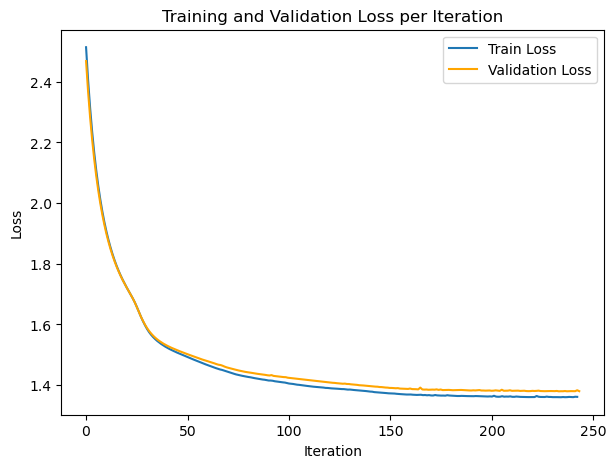

In [5]:
# Plot training and validation loss
plt.figure(figsize=(7,5))
plt.plot(all_train_losses, label="Train Loss")
val_iters = np.linspace(0, len(all_train_losses), len(all_val_losses))
plt.plot(val_iters, all_val_losses, label="Validation Loss", color="orange")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training and Validation Loss per Iteration")
plt.legend()
plt.show()

## analytical based expected value: quicker and precise

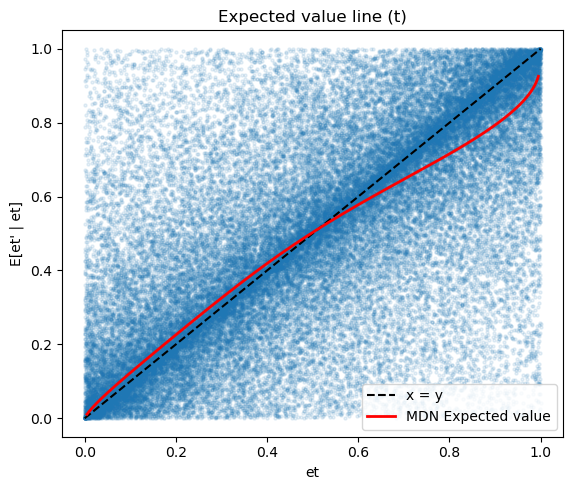

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Define linear input grids (logit space)
n_points = 1000
n_samples = 1

x_grid_t = np.linspace(0.005, 0.995, n_points)
x_grid_t = logit(x_grid_t)  # Transform to logit space

# --- For et using MDN ---
# Repeat each input n_samples times
x_input_t = np.tile(x_grid_t[:, None], (1, n_samples)).flatten()  # shape (n_points*n_samples,1)
x_input_t = x_input_t.reshape(-1,1)

z = apply_fun(params, x_input_t)
alpha, mu, sigma = unpack_mdn_params(z, M, params)

# Compute expected value per input
expected_t = inv_logit(jnp.sum(alpha * mu.squeeze(), axis=1))

# --- Plot ---
plt.figure(figsize=[11,5])

# et plot
plt.subplot(1,2,1)
plt.xlabel("et")
plt.ylabel("E[et' | et]")
plt.title("Expected value line (t)")
plt.scatter(inv_logit(X_train[:,0]), inv_logit(Y_train[:,0]), s=5, alpha=0.1)
plt.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1.5, label="x = y")
plt.plot(inv_logit(x_grid_t), expected_t, color='red', lw=2, label="MDN Expected value")
plt.legend()


plt.tight_layout()
plt.show()

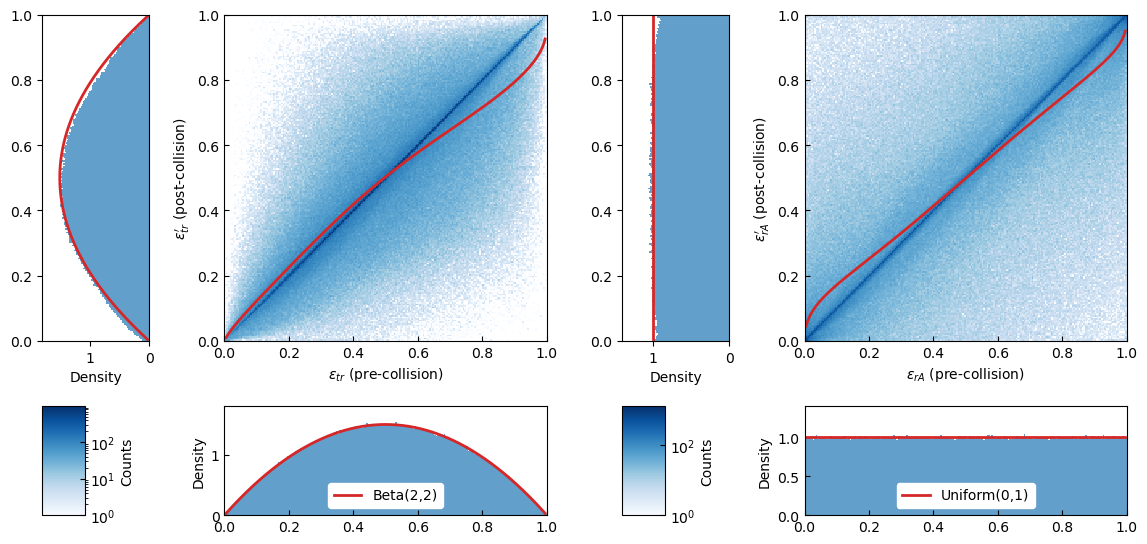

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
from scipy.stats import beta, uniform

# --- Helper functions ---
def logit(p):
    return np.log(p / (1 - p))

def inv_logit(x):
    return 1 / (1 + np.exp(-x))

# --- Input setup ---
n_points = 1000
n_samples = 1_000_000
bins = 200
rng = np.random.default_rng(43)

xs = np.linspace(0.005, 0.995, n_points)


# Input distribution: Beta(2,2)
pdf = beta.pdf(xs, 2, 2)

# Sample x according to Beta(2,2)
rng = np.random.default_rng(42)
x_samples_t = beta.rvs(2, 2, size=n_samples, random_state=rng)

# Transform to logit space if needed by your GMM
x_input_t = logit(x_samples_t).reshape(-1,1)

z = apply_fun(params, x_input_t)
alpha, mu, sigma = unpack_mdn_params(z, M, params)

N, M_, _ = mu.shape
key = random.PRNGKey(0)
key_comp, key_noise = random.split(key)

# Mixture component choice for all samples
comp_idx = random.categorical(key_comp, jnp.log(alpha), shape=(1, N))
mu_s = mu[jnp.arange(N)[:, None], comp_idx.T]       # (N, n_samples, 1)
sigma_s = sigma[jnp.arange(N)[:, None], comp_idx.T] # (N, n_samples, 1)

# Sample Gaussian noise in one shot
noise = random.normal(key_noise, mu_s.shape)
draws = mu_s + noise * sigma_s  # (N, n_samples, 1)

# Map back to [0,1] via inverse logit
# draws[..., 0] corresponds to eps_t_prime
# draws[..., 1] corresponds to eps_rA_prime
eps_prime_fractions = draws  # Shape: (N, n_samples, 1)

eps_t_p = eps_prime_fractions[..., 0]   # Shape: (N, n_samples)

y_samples_t = inv_logit(eps_t_p.squeeze())

# Sample x according to Beta(2,2)
rng = np.random.default_rng(42)
x_samples_rA = beta.rvs(1, 1, size=n_samples, random_state=rng)

# Transform to logit space if needed by your GMM
x_input_rA = logit(x_samples_rA).reshape(-1,1)

z = apply_fun(params_r, x_input_rA)
alpha, mu, sigma = unpack_mdn_params(z, M, params_r)

N, M_, _ = mu.shape
key = random.PRNGKey(0)
key_comp, key_noise = random.split(key)

# Mixture component choice for all samples
comp_idx = random.categorical(key_comp, jnp.log(alpha), shape=(1, N))
mu_s = mu[jnp.arange(N)[:, None], comp_idx.T]       # (N, n_samples, 1)
sigma_s = sigma[jnp.arange(N)[:, None], comp_idx.T] # (N, n_samples, 1)

# Sample Gaussian noise in one shot
noise = random.normal(key_noise, mu_s.shape)
draws = mu_s + noise * sigma_s  # (N, n_samples, 1)

# Map back to [0,1] via inverse logit
# draws[..., 0] corresponds to eps_t_prime
# draws[..., 1] corresponds to eps_rA_prime
eps_prime_fractions = draws  # Shape: (N, n_samples, 1)

eps_rA_p = eps_prime_fractions[..., 0]   # Shape: (N, n_samples)

y_samples_rA = inv_logit(eps_rA_p.squeeze())

x_tr = inv_logit(x_input_t.squeeze())
y_tr = y_samples_t
x_rot = inv_logit(x_input_rA.squeeze())
y_rot = y_samples_rA

# --- Expected value lines ---
x_grid_t = np.linspace(0.005, 0.995, n_points)
x_grid_t = logit(x_grid_t)  # Transform to logit space

# --- For et using MDN ---
# Repeat each input n_samples times
x_input_t = np.tile(x_grid_t[:, None], (1, 1)).flatten()  # shape (n_points*n_samples,1)
x_input_t = x_input_t.reshape(-1,1)

z = apply_fun(params, x_input_t)
alpha, mu, sigma = unpack_mdn_params(z, M, params)

# Compute expected value per input
expected_t = jnp.sum(alpha * mu.squeeze(), axis=1)

x_grid_rA = np.linspace(0.005, 0.995, n_points)
x_grid_rA = logit(x_grid_rA)  # Transform to logit space

# --- For et using MDN ---
# Repeat each input n_samples times
x_input_rA = np.tile(x_grid_rA[:, None], (1, 1)).flatten()  # shape (n_points*n_samples,1)
x_input_rA = x_input_rA.reshape(-1,1)

z = apply_fun(params_r, x_input_rA)
alpha, mu, sigma = unpack_mdn_params(z, M, params_r)

# Compute expected value per input
expected_rA = jnp.sum(alpha * mu.squeeze(), axis=1)

# --- Transform back to probability space ---

# Figure + GridSpec:
fig = plt.figure(figsize=(14, 6.5))
# Make thin margin columns small and 2D columns large
grid = fig.add_gridspec(2, 4,
                        width_ratios=[1, 3.0, 1, 3.0],
                        height_ratios=[3.0, 1],
                        hspace=0.3, wspace=0.35)


# ---- create the 2D panels first so we can share y with the left marginal ----
ax2 = fig.add_subplot(grid[0, 1])   # top-row, 2D translational
h1 = ax2.hist2d(x_tr, y_tr, bins=200, norm=LogNorm(), cmap='Blues')
ax2.plot(inv_logit(x_grid_t), inv_logit(expected_t), color='C3', lw=2, label="Expected value")
ax2.set_xlabel(r"$\varepsilon_{tr}$ (pre-collision)")
ax2.set_ylabel(r"$\varepsilon_{tr}'$ (post-collision)")
ax2.tick_params(direction='in')
#ax2.set_box_aspect(1)   # keep square
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)

ax4 = fig.add_subplot(grid[0, 3])   # top-row, 2D rotational
h2 = ax4.hist2d(x_rot, y_rot, bins=200, norm=LogNorm(), cmap='Blues')
ax4.plot(inv_logit(x_grid_rA), inv_logit(expected_rA), color='C3', lw=2, label="Expected value")
ax4.set_xlabel(r"$\varepsilon_{rA}$ (pre-collision)")
ax4.set_ylabel(r"$\varepsilon_{rA}'$ (post-collision)")
ax4.tick_params(direction='in')
#ax4.set_box_aspect(1)
ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)

# colorbars (adjust fraction/pad so they don't shrink the axes)

# === COLORBARS in bottom row (cols 0 and 2, thinner) ===
ax_cb1 = fig.add_subplot(grid[1, 0])
ax_cb2 = fig.add_subplot(grid[1, 2])

# Create horizontal colorbars with thinner height
cb1 = fig.colorbar(h1[3], cax=ax_cb1, orientation='vertical')
cb2 = fig.colorbar(h2[3], cax=ax_cb2, orientation='vertical')

# Make the colorbars thinner by reducing their width
for cb_ax in [cb1.ax, cb2.ax]:
    pos = cb_ax.get_position()
    # pos = [x0, y0, width, height]
    cb_ax.set_position([pos.x0, pos.y0, 0.4*pos.width, pos.height])

cb1.set_label("Counts")
cb2.set_label("Counts")

# Make ticks point inward
for cb_ax in [ax_cb1, ax_cb2]:
    cb_ax.tick_params(direction='in')


# ---- Top-row thin marginals (horizontal, share y with respective 2D axes) ----
# Left top: post-collision translational (horizontal), share y with ax2
ax1 = fig.add_subplot(grid[0, 0], sharey=ax2)
# horizontal histogram along y; orientation='horizontal'
ax1.hist(y_tr, bins=200, density=True, alpha=0.7, orientation='horizontal')
# plot PDF: for horizontal orientation plot pdf on x vs xs on y
ax1.plot(beta.pdf(xs, 2, 2), xs, '-', color="C3", lw=2, label='Beta(2,2)')
ax1.set_ylim(0, 1)
ax1.set_xlim(0, 1.8)
# invert x so bars extend *towards* the 2D plot
ax1.invert_xaxis()
ax1.set_xlabel("Density")


# Right top: post-collision rotational (horizontal), share y with ax4
ax3 = fig.add_subplot(grid[0, 2], sharey=ax4)
ax3.hist(y_rot, bins=200, density=True, alpha=0.7, orientation='horizontal')
ax3.plot(uniform.pdf(xs, 0, 1), xs, '-', color="C3", lw=2, label='Uniform(0,1)')
ax3.set_ylim(0, 1)
ax3.set_xlim(0, 1.4)
ax3.invert_xaxis()
ax3.set_xlabel("Density")


# ---- Bottom row: thin 1D histograms (pre-collision), keep them horizontal? vertically oriented is fine ----
# Column 2 (bottom middle-left): pre-collision translational
ax5 = fig.add_subplot(grid[1, 1], sharex=ax2)
ax5.hist(x_tr, bins=200, density=True, alpha=0.7)
ax5.plot(xs, beta.pdf(xs, 2, 2), '-', color="C3", lw=2, label="Beta(2,2)")
# ax5.plot(beta.pdf(xs, 2, 2)*-1, xs, '-', color="orange", lw=2, label='Beta(2,2)')
ax5.set_xlim(0, 1)
ax5.set_ylim(0, 1.8)
# ax5.set_xlabel(r"$\varepsilon_{tr}$ (pre-collision)")
ax5.set_ylabel("Density")
ax5.legend(facecolor='white', framealpha=1.0, loc='lower center', edgecolor='white')
ax5.tick_params(direction='in')

# Column 4 (bottom right): pre-collision rotational
ax6 = fig.add_subplot(grid[1, 3], sharex=ax2)
ax6.hist(x_rot, bins=200, density=True, alpha=0.7)
ax6.plot(xs, uniform.pdf(xs, 0, 1), '-', color="C3", lw=2, label="Uniform(0,1)")
ax6.set_xlim(0, 1)
ax6.set_ylim(0, 1.4)
# ax6.set_xlabel(r"$\varepsilon_{rA}$ (pre-collision)")
ax6.set_ylabel("Density")
ax6.legend(facecolor='white', framealpha=1.0, loc='lower center', edgecolor='white')
ax6.tick_params(direction='in')

plt.show()

In [9]:
from scipy.stats import wasserstein_distance

W = wasserstein_distance(y_tr, x_tr)
print(f"Wasserstein(y_tr vs x_tr (Beta(2,2))) = {W:.5f}")

W = wasserstein_distance(y_rot, x_rot)
print(f"Wasserstein(y_rot vs x_rot (Beta(1,1))) = {W:.5f}")


n_points = 1000
xs = np.linspace(0.005, 0.995, n_points)
pdf = beta.pdf(xs, 2, 2)  # Beta(2,2)
expected_value = np.sum(expected_t * pdf) / np.sum(pdf) 

print(inv_logit(expected_value))

pdf = beta.pdf(xs, 1, 1)  # Beta(2,2)
expected_value = np.sum(expected_rA * pdf) / np.sum(pdf) 

print(inv_logit(expected_value))

Wasserstein(y_tr vs x_tr (Beta(2,2))) = 0.01517
Wasserstein(y_rot vs x_rot (Beta(1,1))) = 0.00356
0.478553481264175
0.49899752666733727


In [13]:
from scipy.stats import beta, uniform

n_points = 1000

xs = np.linspace(0.005, 0.995, n_points)
pdf = beta.pdf(xs, 2, 2)  # Beta(2,2)

expected_value = np.sum(expected_t * pdf) / np.sum(pdf) 

print(expected_value) # looks like correct constraint, may need second constraint (2nd moment, the beta(2,2) should also come out of the kernel), try out by training model with this constraint?
print(inv_logit(expected_value))
#  0.0462 -> T_rot ~ 281K (gamma3_2 10K) 128N 10M
#  0.0122 -> T_rot ~ 290K (Uniform 10K) MDN: 128N 10M DSMC: 100K particles +0.5K
#  0.0100 -> T_rot ~ 292K (Uniform 10K) MDN: 128N 10M DSMC: 100K particles +0.5K
#  0.0042 -> T_rot ~ 295K (Uniform 10K) MDN: 128N 10M DSMC: 100K particles +0.5K
#  0.0032 -> T_rot ~ 299K (Uniform 10K) 128N 10M
#  0.0004 -> T_rot ~ 302K (Uniform 10K) MDN: 128N 10M DSMC: 100K particles +0.5K
# -0.0012 -> T_rot ~ 301K (Uniform 10K) 8N  10M
# -0.0026 -> T_rot ~ 301K (Uniform 10K) MDN: 128N 10M DSMC: 100K particles +0.5K
# -0.0027 -> T_rot ~ 306K (Uniform 10K) 8N 20M
# -0.0046 -> T_rot ~ 305K (Uniform 10K) 8N 10M
# -0.0121 -> T_rot ~ 310K (Uniform 10K) MDN: 128N 10M DSMC: 100K particles +0.5K
# -0.0131 -> T_rot ~ 308K (Uniform 1M) 8N 10M
# -0.0136 -> T_rot ~ 312K (Uniform 10K) MDN: 128N 10M DSMC: 100K particles +0.5K
# -0.0151 -> T_rot ~ 311K (Uniform 1M) 8N 20M
# -0.0156 -> T_rot ~ 308K (Uniform 100K) 128N 10M
# -0.0293 -> T_rot ~ 319K (Uniform 100K) 128N 10M
# -0.0293 -> T_rot ~ 323K (Uniform 10K) MDN: 128N 10M DSMC: 100K particles +0.5K
# -0.0458 -> T_rot ~ 329K (gamma3_12 100K) 128N 10M
# -0.0721 -> T_rot ~ 349K (gamma3 100K) 8N 20M DSMC: 100K particles +0.5K
# -0.0927 -> T_rot ~ 350K (DSMC sampling 100K) 128N 10M
# -0.1252 -> T_rot ~ 355K (300K 100K) 128N 10M


0.0019503016
0.5004875790617451


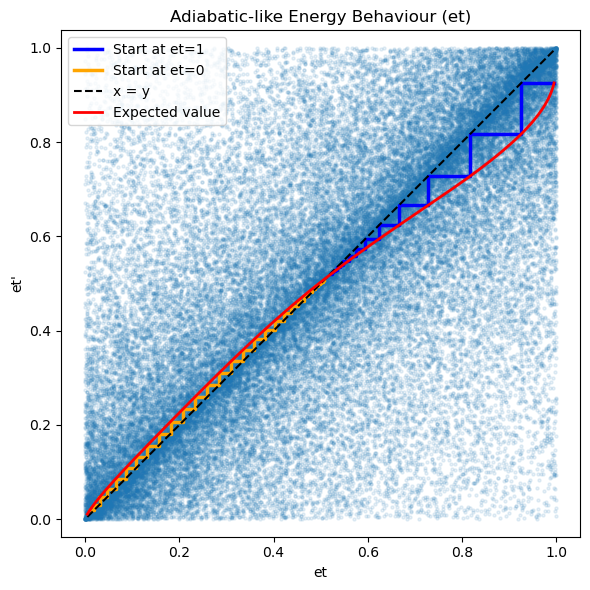

In [15]:
# Prepare plotting variables
x_vals = inv_logit(x_grid_t)
y_exp = expected_t
y_identity = x_vals

# Helper to find nearest value on curve
def find_nearest_index(array, value):
    return np.argmin(np.abs(array - value))

def make_bounce_path(x_vals, y_exp, start_x, n_steps=5):
    """
    Create a 'bouncing' step path that alternates horizontally to x=y line 
    and vertically to the expected curve.
    """
    path_x = []
    path_y = []

    # Start at expected line
    i = find_nearest_index(x_vals, start_x)
    x, y = x_vals[i], y_exp[i]

    path_x.append(x)
    path_y.append(y)

    going_to_identity = True

    for _ in range(n_steps):
        if going_to_identity:
            # Horizontal step to x=y line
            y_target = y
            x_target = y_target  # since y=x on the identity line
        else:
            # Vertical step back to expected line
            i_target = find_nearest_index(x_vals, x)
            x_target = x_vals[i_target]
            y_target = y_exp[i_target]

        # Add this segment
        path_x.extend([path_x[-1], x_target])
        path_y.extend([path_y[-1], y_target])

        # Update current point and toggle direction
        x, y = x_target, y_target
        going_to_identity = not going_to_identity

    return path_x, path_y


# Create the two bounce paths
x_step_pos, y_step_pos = make_bounce_path(x_vals, inv_logit(y_exp), start_x=1, n_steps=30)
x_step_neg, y_step_neg = make_bounce_path(x_vals, inv_logit(y_exp), start_x=0.01, n_steps=60)

# --- Plot ---
plt.figure(figsize=[6,6])
plt.xlabel("et")
plt.ylabel("et'")
plt.title("Adiabatic-like Energy Behaviour (et)")

# Scatter for reference
plt.scatter(inv_logit(X_train[:, 0]), inv_logit(Y_train[:, 0]), s=5, alpha=0.1)



# Step/bounce paths
plt.plot(x_step_pos, y_step_pos, color='blue', lw=2.5, drawstyle='steps-pre', label="Start at et=1")
plt.plot(x_step_neg, y_step_neg, color='orange', lw=2.5, drawstyle='steps-pre', label="Start at et=0")
plt.xlim(0, 1)
plt.ylim(0, 1)

# Expected and identity lines
plt.plot(x_vals, y_identity, color='black', linestyle='--', lw=1.5, label="x = y")
plt.plot(x_vals, inv_logit(y_exp), color='red', lw=2, label="Expected value")

plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()

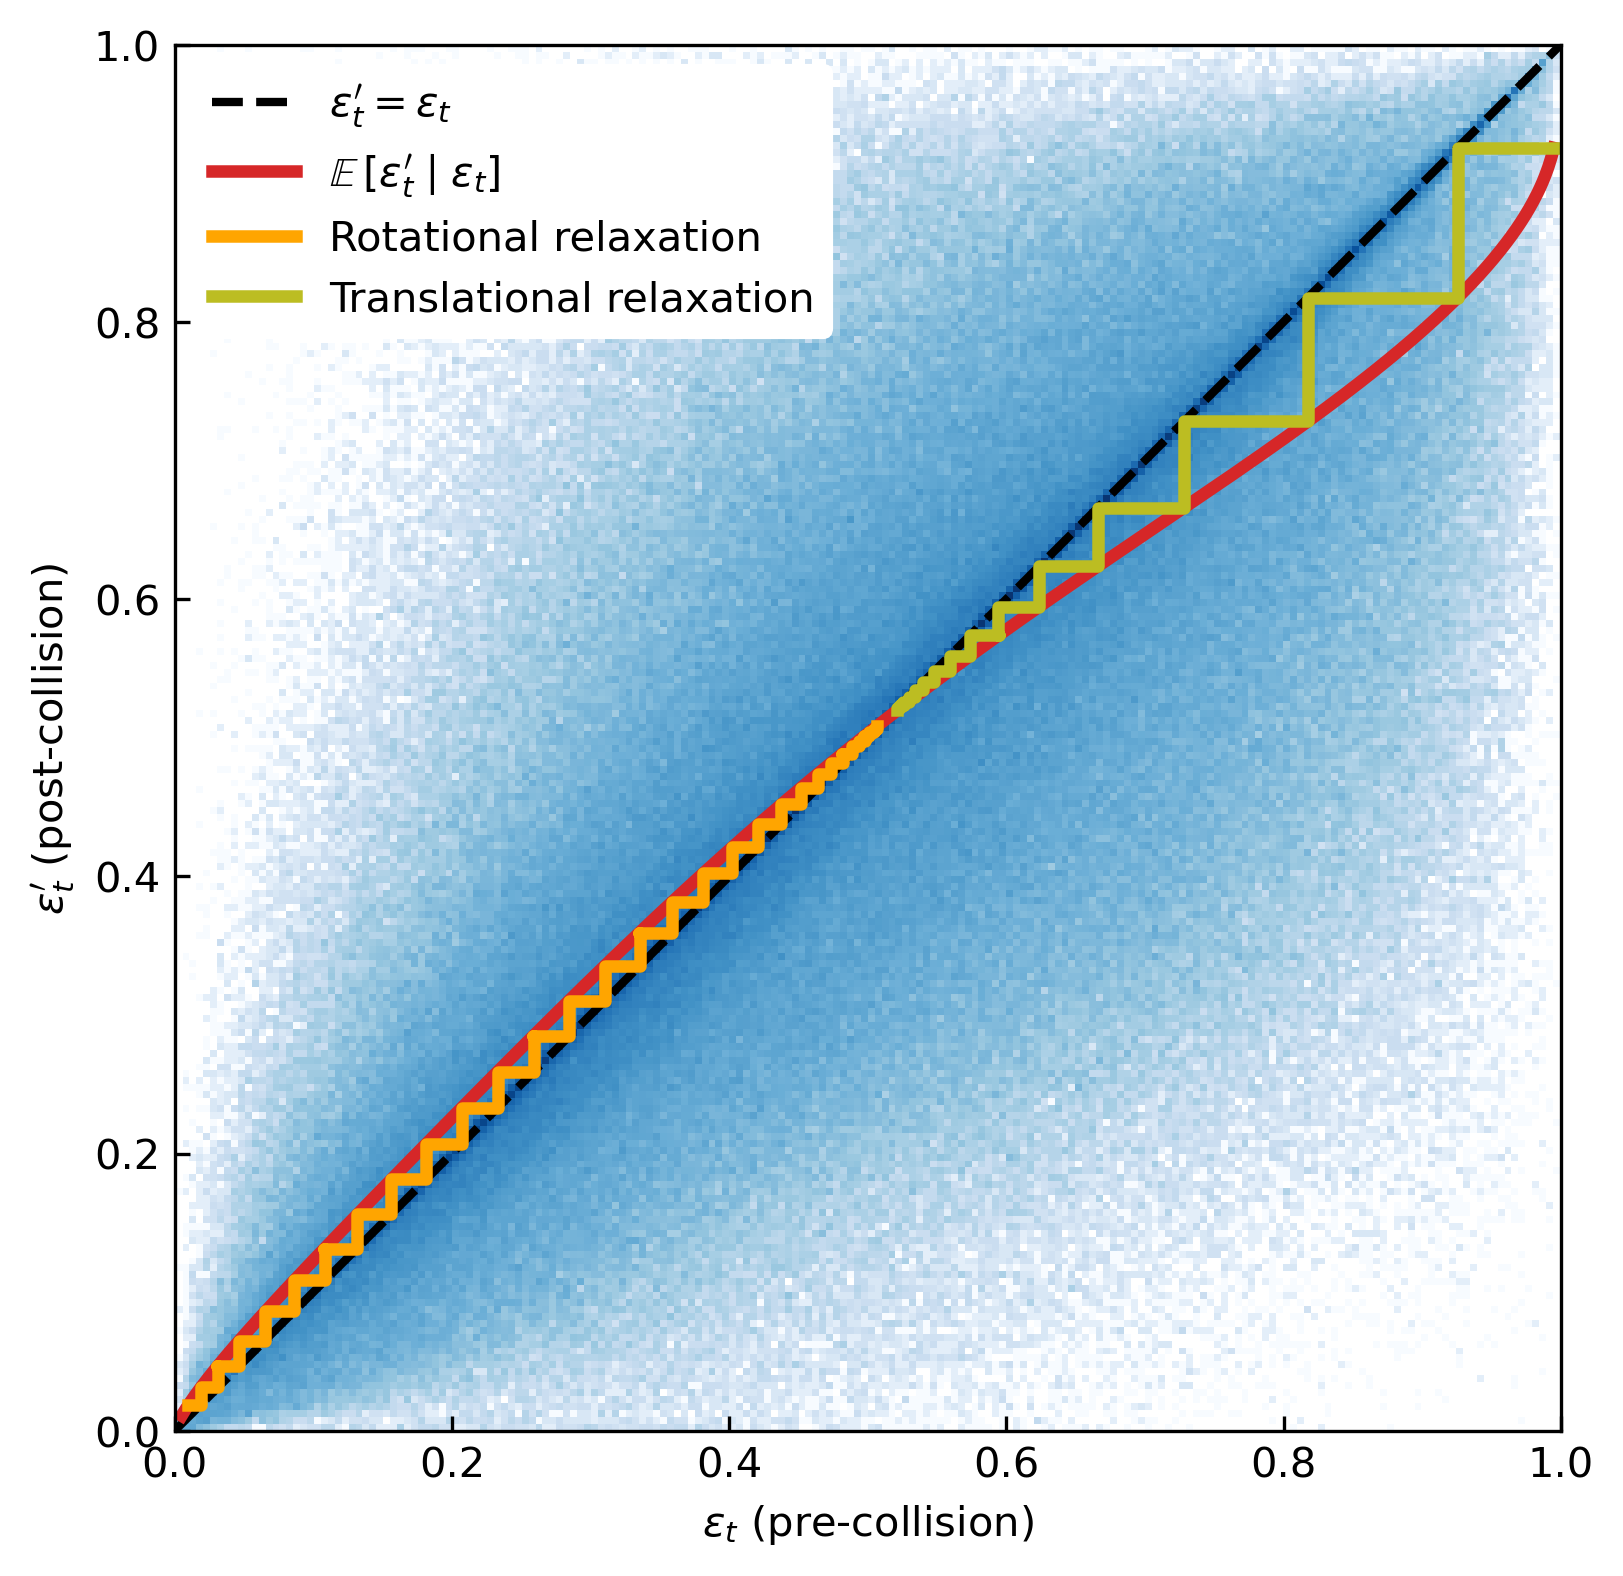

In [17]:
from matplotlib.colors import LogNorm

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
# ---- eps_t ----
h = ax.hist2d(
    x_samples_t,
    y_samples_t,
    bins=200,
    norm=LogNorm(),
    cmap='Blues',
)

# 3. Add labels and a color bar
ax.plot([0, 1], [0, 1], color='black', linestyle='--', lw=2, alpha=1, label=r"$\varepsilon_t' = \varepsilon_t$")
ax.plot(inv_logit(x_grid_t), inv_logit(expected_t), color='C3', lw=3,  label=r"$\mathbb{E}\,[\varepsilon_t' \mid \varepsilon_t]$")
ax.plot(x_step_neg, y_step_neg, color='orange', lw=3, drawstyle='steps-pre', label="Rotational relaxation")
ax.plot(x_step_pos, y_step_pos, color='C8', lw=3, drawstyle='steps-pre', label="Translational relaxation")
plt.xlim(0, 1)
plt.ylim(0, 1)
ax.tick_params(direction='in')
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel(r"$\varepsilon_{t}$ (pre-collision)")
ax.set_ylabel(r"$\varepsilon_{t}'$ (post-collision)")
# fig.colorbar(h[3], ax=ax, label="Counts")
plt.legend(facecolor='white', framealpha=1, loc='upper left', edgecolor='white')

# 4. Display the plot
plt.show()

# DSMC - termal equilibrium

In [6]:
import time
from scipy.stats import maxwell

# ---------------------------
# Physical & simulation params
# ---------------------------
n_particles = 10_000        # increase for better statistics
T0 = 300.0                 # Kelvin (initial equilibrium temperature)
kB = 1.38064852e-23
m_H = 1.6738e-27
m_molecule = 2.0 * m_H     # diatomic identical masses
mu_pair = 0.5 * m_molecule  # reduced mass for identical molecules

# DSMC timestepping
dt = 1e-4
t_end = 0.025 # 0.025 or 0.1
n_steps = int(jnp.ceil(t_end / dt))

snapshot_times = [0.0, 0.013, 0.025, 0.05, 0.75, 0.100]
snapshots = []

# collision candidate batch size per timestep
n_cand = max(200, n_particles // 2)

# PRNG key (JAX)
key = jax.random.PRNGKey(1234)

# ---------------------------
# Utility (same transforms used in training)
# ---------------------------

def preprocess_X_batch_jax(Etr_batch, Er_i_batch, Er_j_batch):
    """
    Vectorized preprocessing for MDN inputs (JAX).
    Inputs arrays shape (Npairs,)
    Returns X_batch (Npairs,3), Ec_batch (Npairs,)
    """
    Ec = Etr_batch + Er_i_batch + Er_j_batch
    E_rot_total = Er_i_batch + Er_j_batch
    eps_t = Etr_batch / (Ec+1e-12)
    eps_r_A = Er_i_batch / (E_rot_total+1e-12)
    # use jnp.log and logit_jnp
    X1 = jnp.log(Ec+1e-12)
    X2 = logit(eps_t)
    X3 = logit(eps_r_A)
    X = jnp.stack([X2], axis=1)
    return X.astype(jnp.float32), Ec

# ---------------------------
# Initialize particles (thermal equilibrium)
# Keep only total rotational energy Er (sum of two mode energies)
# ---------------------------
key, sk = jax.random.split(key)
v_tr = jax.random.normal(sk, (n_particles, 3)) * jnp.sqrt(kB * 167 / m_molecule) #167

# sample Er_total as Gamma(k=1, scale=kB*T0) using JAX
key, sk = jax.random.split(key)
Er = jax.random.gamma(sk, 1.0, (n_particles,)) * (kB * 1000)  # total rotational energy per particle

# convert to numpy for some plotting functions that expect numpy later
v_tr = jnp.array(v_tr)
Er = jnp.array(Er)

# ---------------------------
# Helper: generate disjoint candidate pairs & accept by relative speed (JAX)
# ---------------------------
def select_disjoint_candidates_and_accept(key1, v_tr, n_cand):
    """
    Produce disjoint candidate pairs by random permutation:
      - permute indices, take first 2*n_cand indices, reshape to (n_cand,2)
    Accept each pair with probability g/gmax (relative speed weighting).
    Returns:
      key, i_acc (array), j_acc (array), g_acc (array), gmax (scalar)
    """
    N = v_tr.shape[0]
    key2, kperm, kune = jax.random.split(key1, 3)
    perm = jax.random.permutation(kperm, N)
    # if 2*n_cand > N, reduce n_cand to floor(N/2)
    max_pairs = N // 2
    n_cand_eff = jnp.minimum(n_cand, max_pairs)
    idx2 = perm[:2 * n_cand_eff]
    pairs = idx2.reshape((n_cand_eff, 2))
    i_cand = pairs[:, 0]
    j_cand = pairs[:, 1]
    v_rel = v_tr[i_cand] - v_tr[j_cand]
    g = jnp.linalg.norm(v_rel, axis=1)
    gmax = jnp.maximum(g.max(), 1e-12)
    p = g / gmax
    u = jax.random.uniform(kune, shape=(n_cand_eff,))
    accept_mask = u < p
    i_acc = i_cand[accept_mask]
    j_acc = j_cand[accept_mask]
    g_acc = g[accept_mask]
    return key2, i_acc, j_acc, g_acc, gmax

# ---------------------------
# Batch collision processing (JAX vectorized)
# ---------------------------
@jax.jit
def process_pairs_batch_jax(params, params_r, key1, v_i_arr, v_j_arr, Er_i_arr, Er_j_arr):
    """
    Vectorized processing of accepted disjoint pairs in JAX.
    Inputs: arrays (Npairs, ...) as jnp arrays.
    Returns: v_i_new, v_j_new, Er_i_post, Er_j_post, key
    """
    n_pairs = v_i_arr.shape[0]
    # If zero pairs, return empty arrays quickly
    def zero_return():
        return (jnp.zeros((0, 3)), jnp.zeros((0, 3)), jnp.zeros((0,)), jnp.zeros((0,)), key1)

    if n_pairs == 0:
        return zero_return()

    # 1) Compute pair translational energy (relative speed)
    v_rel = v_i_arr - v_j_arr  # (n_pairs,3)
    g2 = jnp.sum(v_rel**2, axis=1)  # (n_pairs,)
    Etr_pair = 0.5 * mu_pair * g2  # (n_pairs,)

    # 2) Preprocess X batch & Ec batch for MDN
    X_batch, Ec_batch = preprocess_X_batch_jax(Etr_pair/kB, Er_i_arr/kB, Er_j_arr/kB)  # shapes (n_pairs,3), (n_pairs,)

    # 3) Call MDN once for whole batch
    # Provide per-batch key for MDN sampling:
    key2, kmdn = jax.random.split(key1,2)
    Etrp_batch, Er_i_post_batch, Er_j_post_batch = mdn_sample_conserve(params, params_r, X_batch, Ec_batch, n_samples=1, key=kmdn)
    # Etrp_batch, Er_i_post_batch, Er_j_post_batch = gmm_sample_conserve(X_batch, Ec_batch, n_samples=1, key=kmdn)
    # ensure shape (n_pairs,) for each
    Etrp_batch = jnp.squeeze(jnp.array(Etrp_batch)).reshape(-1)*kB
    Er_i_post_batch = jnp.squeeze(jnp.array(Er_i_post_batch)).reshape(-1)*kB
    Er_j_post_batch = jnp.squeeze(jnp.array(Er_j_post_batch)).reshape(-1)*kB

    # jax.debug.print("Etrp_batch: {eb}", eb=(Etr_pair/kB).mean())

    # 4) Reconstruct new velocities:
    # sample isotropic directions via two uniforms per pair
    key3, kunif = jax.random.split(key2,2)
    u = jax.random.uniform(kunif, (n_pairs, 2))
    u1 = u[:, 0]; u2 = u[:, 1]
    theta = 2.0 * jnp.pi * u1
    phi = jnp.arccos(2.0 * u2 - 1.0)
    sinphi = jnp.sin(phi)
    dir_new = jnp.stack([sinphi * jnp.cos(theta), sinphi * jnp.sin(theta), jnp.cos(phi)], axis=1)  # (n_pairs,3)

    # g_new and relative velocity
    g_new = jnp.sqrt(jnp.maximum(2.0 * Etrp_batch / mu_pair, 0.0))
    v_rel_new = dir_new * g_new[:, None]  # (n_pairs,3)

    v_cm = 0.5 * (v_i_arr + v_j_arr)
    v_i_new = v_cm + 0.5 * v_rel_new
    v_j_new = v_cm - 0.5 * v_rel_new

    return v_i_new, v_j_new, Er_i_post_batch, Er_j_post_batch, key3

# ---------------------------
# Main DSMC loop (Python driver, heavy ops in JAX)
# ---------------------------
t0 = time.time()
times = []
Ttr_list = []
Trot_list = []

# initial temps
T_tr_init = float(jnp.mean(jnp.sum(v_tr**2, axis=1) * m_molecule / (3.0 * kB)))
T_rot_init = float(jnp.mean(Er) / (kB))
print(f"Initial T_tr = {T_tr_init:.3f} K, T_rot = {T_rot_init:.3f} K")

for step in range(n_steps + 1):
    t = step * dt
    # record temps
    T_tr = float(jnp.mean(jnp.sum(v_tr**2, axis=1) * m_molecule / (3.0 * kB)))
    T_rot = float(jnp.mean(Er) / (kB))
    times.append(t)
    Ttr_list.append(T_tr)
    Trot_list.append(T_rot)

    # Save snapshots
    if any(abs(t - st) < dt/2 for st in snapshot_times):
        snapshots.append({
            "time": t,
            "v_tr": np.array(v_tr),
            "Er": np.array(Er),
        })

    if step == n_steps:
        break

    # select disjoint candidate pairs & accept by relative speed (JAX)
    key, i_acc, j_acc, g_acc, gmax = select_disjoint_candidates_and_accept(key, v_tr, n_cand)

    n_acc = i_acc.shape[0]
    if n_acc == 0:
        continue

    print(f"t={t:.4f}s: {n_acc} accepted collisions (gmax={float(gmax):.2e})")

    # gather arrays for accepted pairs (convert to jnp arrays)
    v_i_arr = v_tr[i_acc]
    v_j_arr = v_tr[j_acc]
    Er_i_arr = Er[i_acc]
    Er_j_arr = Er[j_acc]

    # process batch in JAX
    v_i_new_arr, v_j_new_arr, Er_i_new_arr, Er_j_new_arr, key = process_pairs_batch_jax(
        params, params_r, key, v_i_arr, v_j_arr, Er_i_arr, Er_j_arr
    )

    # scatter-update (JAX indexed updates)
    v_tr = v_tr.at[i_acc].set(v_i_new_arr)
    v_tr = v_tr.at[j_acc].set(v_j_new_arr)
    Er = Er.at[i_acc].set(Er_i_new_arr)
    Er = Er.at[j_acc].set(Er_j_new_arr)

    print(f"t = {t:.4f} s, T_tr = {T_tr:.3f} K, T_rot = {T_rot:.3f} K")

t1 = time.time()
print(f"Simulation done in {t1 - t0:.2f} s")

Initial T_tr = 166.617 K, T_rot = 1002.632 K
t=0.0000s: 1836 accepted collisions (gmax=5.15e+03)
t = 0.0000 s, T_tr = 166.617 K, T_rot = 1002.632 K
t=0.0001s: 1815 accepted collisions (gmax=5.41e+03)
t = 0.0001 s, T_tr = 176.684 K, T_rot = 987.533 K
t=0.0002s: 1753 accepted collisions (gmax=5.68e+03)
t = 0.0002 s, T_tr = 187.238 K, T_rot = 971.701 K
t=0.0003s: 1544 accepted collisions (gmax=6.50e+03)
t = 0.0003 s, T_tr = 198.046 K, T_rot = 955.489 K
t=0.0004s: 1547 accepted collisions (gmax=6.42e+03)
t = 0.0004 s, T_tr = 204.926 K, T_rot = 945.170 K
t=0.0005s: 1606 accepted collisions (gmax=6.61e+03)
t = 0.0005 s, T_tr = 214.048 K, T_rot = 931.487 K
t=0.0006s: 1636 accepted collisions (gmax=6.66e+03)
t = 0.0006 s, T_tr = 222.617 K, T_rot = 918.634 K
t=0.0007s: 1583 accepted collisions (gmax=6.86e+03)
t = 0.0007 s, T_tr = 231.073 K, T_rot = 905.949 K
t=0.0008s: 1602 accepted collisions (gmax=6.90e+03)
t = 0.0008 s, T_tr = 240.287 K, T_rot = 892.128 K
t=0.0009s: 1589 accepted collisions 

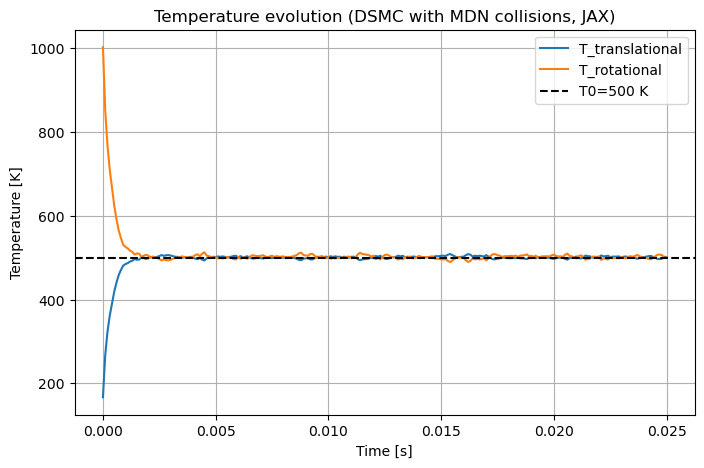

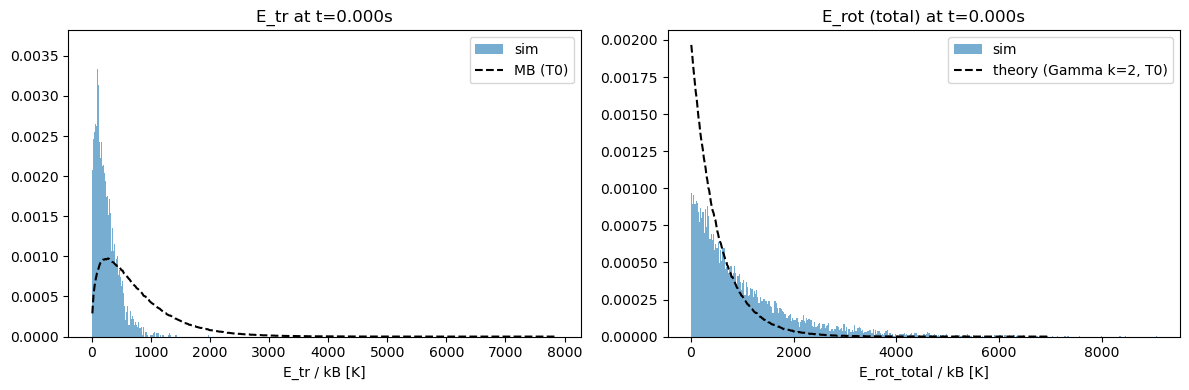

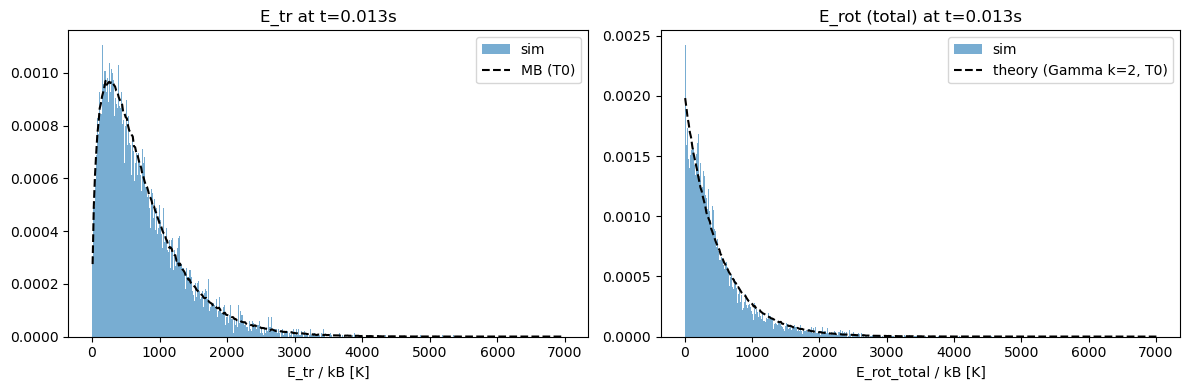

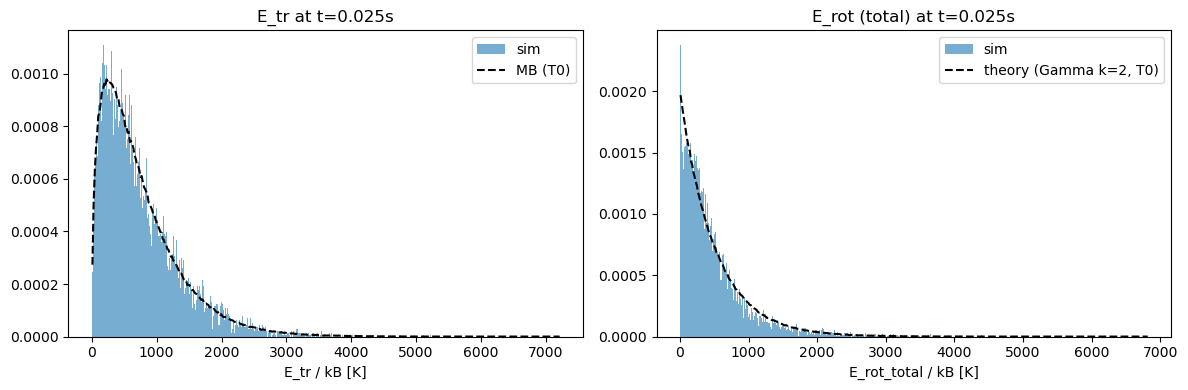

In [6]:

# ---------------------------
# Plot temperatures
# ---------------------------
T0=500
plt.figure(figsize=(8,5))
plt.plot(times, Ttr_list, label="T_translational")
plt.plot(times, Trot_list, label="T_rotational")
plt.axhline(T0, color="k", linestyle="--", label=f"T0={T0} K")
plt.xlabel("Time [s]")
plt.ylabel("Temperature [K]")
plt.legend()
plt.title("Temperature evolution (DSMC with MDN collisions, JAX)")
plt.grid(True)
plt.show()

# ---------------------------
# Histograms at snapshots
# ---------------------------
def plot_energy_histograms(snapshot):
    t = snapshot["time"]
    v_tr_snap = snapshot["v_tr"]
    Etr_snap = 0.5 * m_molecule * np.sum(v_tr_snap**2, axis=1) / kB  # Kelvin units
    Erot_snap = snapshot["Er"] / kB

    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    # Translational
    ax = axes[0]
    ax.hist(Etr_snap, bins=400, density=True, alpha=0.6, label="sim")
    samp_v = maxwell.rvs(scale=np.sqrt(kB*T0/m_molecule), size=1000000)
    samp_E = 0.5 * m_molecule * samp_v**2 / kB
    hist_s, be = np.histogram(samp_E, bins=400, density=True)
    bc = 0.5*(be[:-1]+be[1:])
    ax.plot(bc, hist_s, 'k--', label="MB (T0)")
    ax.set_xlabel("E_tr / kB [K]")
    ax.set_title(f"E_tr at t={t:.3f}s")
    ax.legend()

    # Rotational
    ax = axes[1]
    ax.hist(Erot_snap, bins=400, density=True, alpha=0.6, label="sim")
    samp_rot = np.random.gamma(shape=1.0, scale=kB*T0, size=1000000) / kB
    hist_s_r, be_r = np.histogram(samp_rot, bins=400, density=True)
    bc_r = 0.5*(be_r[:-1]+be_r[1:])
    ax.plot(bc_r, hist_s_r, 'k--', label="theory (Gamma k=2, T0)")
    ax.set_xlabel("E_rot_total / kB [K]")
    ax.set_title(f"E_rot (total) at t={t:.3f}s")
    ax.legend()

    plt.tight_layout()
    plt.show()

for snap in snapshots:
    plot_energy_histograms(snap)